# VQCFD Results Analysis

The reusable logic lives in `analysis.py`. This notebook only contains run selections and plotting options.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover saved runs


In [21]:
# Each filter accepts one value, a list of values, or None for every value.
NS = [2,3,4]                # e.g. 3 or [2, 3, 4]
LS = None                 # e.g. 2 or [1, 2, 3]
CIRCUITS = ["all_to_all_crx","block_crx","ring_trainable_crz","ghz_orbit","local_ry_rz"]           # e.g. "multiscale_tree" or ["default", "uni2"]
INITIAL_STATES = None     # e.g. "sine" or ["sine", "tapered_gaussian"]
MODES = None              # e.g. "noise_free" or ["variance", "gradient"]

runs = an.list_runs(
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    modes=MODES,
)
an.print_runs(runs)


 N  L            Circuit Initial state       Mode  Parameters  Saved  Variance
 2  4     all_to_all_crx          sine noise_free          14   True     False
 2  4          block_crx          sine noise_free          14   True     False
 2  4          ghz_orbit          sine noise_free          16   True     False
 2  4        local_ry_rz          sine noise_free          20   True     False
 2  4 ring_trainable_crz          sine noise_free          14   True     False
 3  4     all_to_all_crx          sine noise_free          27   True     False
 3  4          block_crx          sine noise_free          27   True     False
 3  4          ghz_orbit          sine noise_free          24   True     False
 3  4        local_ry_rz          sine noise_free          30   True     False
 3  4 ring_trainable_crz          sine noise_free          27   True     False
 4  4     all_to_all_crx          sine noise_free          44   True     False
 4  4          block_crx          sine noise_free   

In [248]:
# Optional filters: n=..., l=...
preset_rows = an.list_initial_param_presets(n = 6, circuit="multiscale_tree", show_variants=False)


N=6, L=1 | default_len=13 | default_mse=0.026308669655778574
N=6, L=2 | default_len=19 | default_mse=0.00034216808447705345
N=6, L=3 | default_len=25 | default_mse=0.00022093751229731567
N=6, L=4 | default_len=31 | default_mse=1.4132765958221204e-06
N=6, L=5 | default_len=37 | default_mse=2.6986324565342634e-06
N=6, L=6 | default_len=43 | default_mse=1.5119335353666355e-06
N=6, L=7 | default_len=49 | default_mse=1.4055003835099423e-07
N=6, L=8 | default_len=55 | default_mse=5.47238702094108e-07
count=8 presets


## Inspect one run


In [ ]:
DIR_LABEL = "N3"
LABEL = "L2"

run = an.load_run(DIR_LABEL, LABEL)
run


RunData(dir_label='N5', label='L5', full_label='N5_L5', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/figures_L5'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N5/data_L5', 'dir_label': 'N5', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N5/figures_L5', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 5, 'label': 'L5', 'manifest_path': 'results/results_N5/manifest_N5_L5.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 5, 'n_timesteps': 28, 'n_total': 32, 'optimization_steps': 1000, 'pa

In [4]:
print("manifest path:", run.files["manifest"])
print("values yaml path:", run.files["values_yaml"])
print("values keys:", list(run.values.keys()))
run.values


manifest path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/manifest_N5_L5.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5/values_N5_L5.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'expressibility', 'entangling_capability', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 5,
 'l': 5,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'initial_params_source': 'preset',
 'expressibility': 0.12782413492695527,
 'entangling_capability': 0.8318029744040429,
 'initial_fit_mse': 1.0888691785137848e-08,
 'shots_used_per_timestep': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'shots_used_total': 0}

In [17]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print("costs:", None if costs is None else costs.shape)
print("times:", None if times is None else times.shape)
print("params:", None if params is None else params.shape)
print("variance:", variance)


costs: (28,)
times: (28,)
params: (29, 21)
variance: None


In [18]:
cost_histories = an.load_per_timestep_histories(run, "cost_iter")
param_histories = an.load_per_timestep_histories(run, "params_iter")
print("cost_iter timesteps:", len(cost_histories))
print("params_iter timesteps:", len(param_histories))


cost_iter timesteps: 28
params_iter timesteps: 0


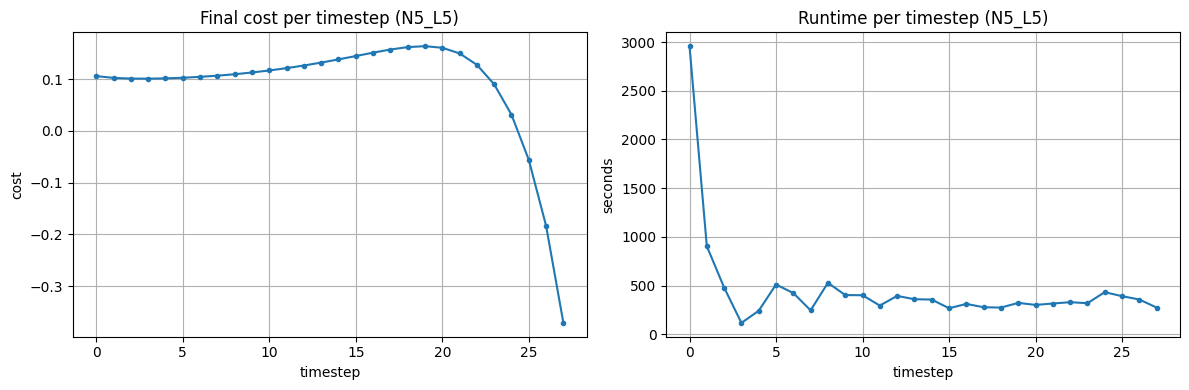

In [5]:
an.plot_costs_and_times(run);


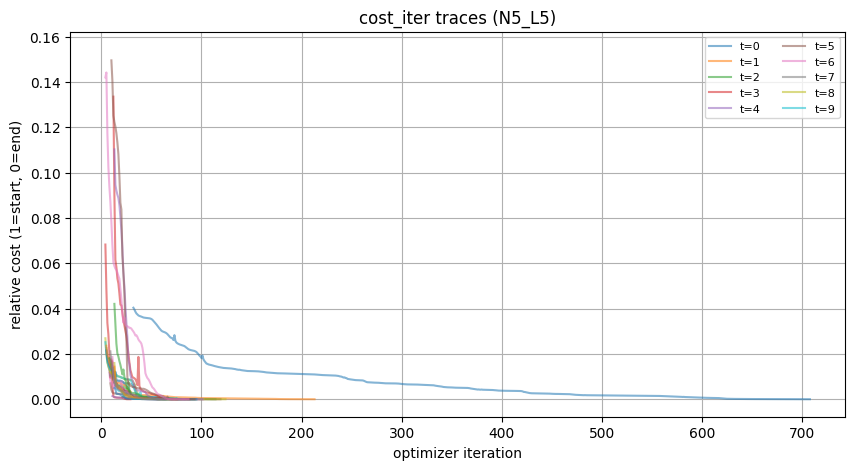

In [6]:
an.plot_cost_histories(
    run,
    normalize=True,
    remove_outliers=True,
    outlier_method="iqr",       # "iqr" or "percentile"
    outlier_factor=3.0,
    outlier_percentiles=(1.0, 99.0),
    show_first_n_labels=10,
);


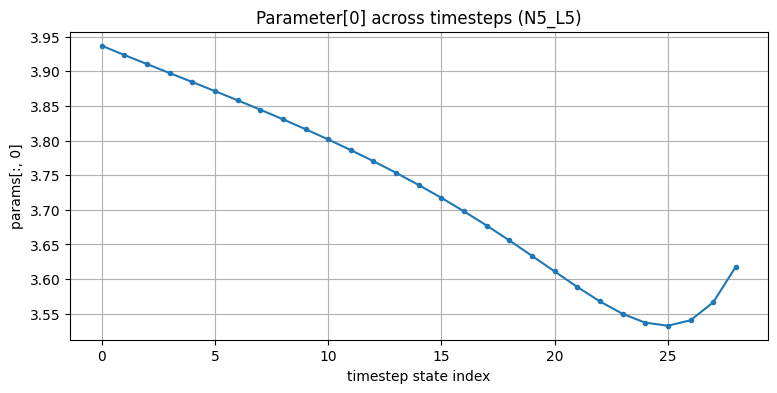

In [7]:
an.plot_parameter_history(run, parameter_index=0);


shots_used_total: 0


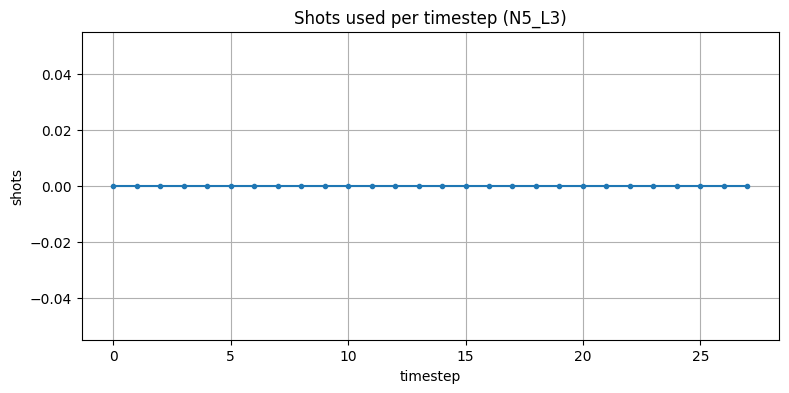

In [ ]:
an.plot_shots(run);

## Classical and quantum fields at one timestep

Use `TIMESTEP = 0` for the initial state, a positive saved-state index, or `-1` for the final state. The plot reports MSE, R², and normalized squared-overlap fidelity.


In [53]:
DIR_LABEL = "N4"
LABEL = "L3"

run = an.load_run(DIR_LABEL, LABEL)
run

RunData(dir_label='N4', label='L3', full_label='N4_L3', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N4'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N4/data_L3'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N4/figures_L3'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N4/data_L3', 'dir_label': 'N4', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N4/figures_L3', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 3, 'label': 'L3', 'manifest_path': 'results/results_N4/manifest_N4_L3.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 4, 'n_timesteps': 28, 'n_total': 16, 'optimization_steps': 1000, 'pa

timestep                       2.800000e+01
time                           2.800000e-01
MSE                            3.911726e-07
R2                             9.999996e-01
Fidelity                       9.999996e-01
RelativeL1Error                6.654247e-04
RelativeL2Error                6.272321e-04
RelativeLinfError              7.830627e-04
RelativeDerivativeL2Error      7.266467e-04
RelativeDerivativeLinfError    6.785426e-04
RelativeMassError                       NaN
NormalizedMassDrift            3.440001e-01
dtype: float64

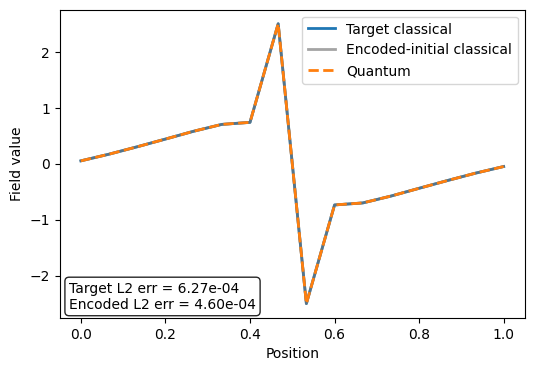

In [54]:
TIMESTEP = -1

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})


In [55]:
fig.savefig(f"figures/single_runs/single_run_{DIR_LABEL}_{LABEL}.pdf", bbox_inches='tight')

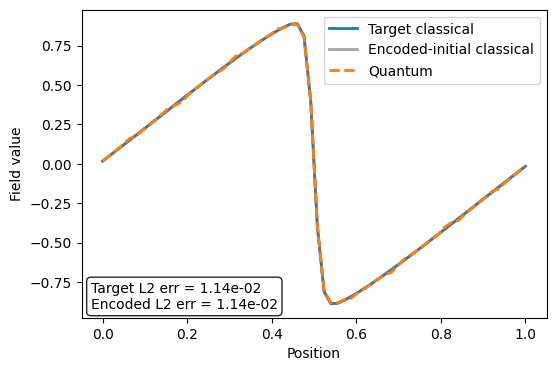

In [59]:
DIR_LABEL = "N6"
LABEL = "L6"

run = an.load_run(DIR_LABEL, LABEL)
TIMESTEP = -1

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})

fig.savefig(f"figures/single_runs/single_run_{DIR_LABEL}_{LABEL}.pdf", bbox_inches='tight')

## Classical and quantum fields over the whole time evolution

Choose `EVOLUTION_FIELDS = "classical"`, `"quantum"`, or `"both"`. Increase `TIMESTEP_STRIDE` to show fewer saved timesteps.


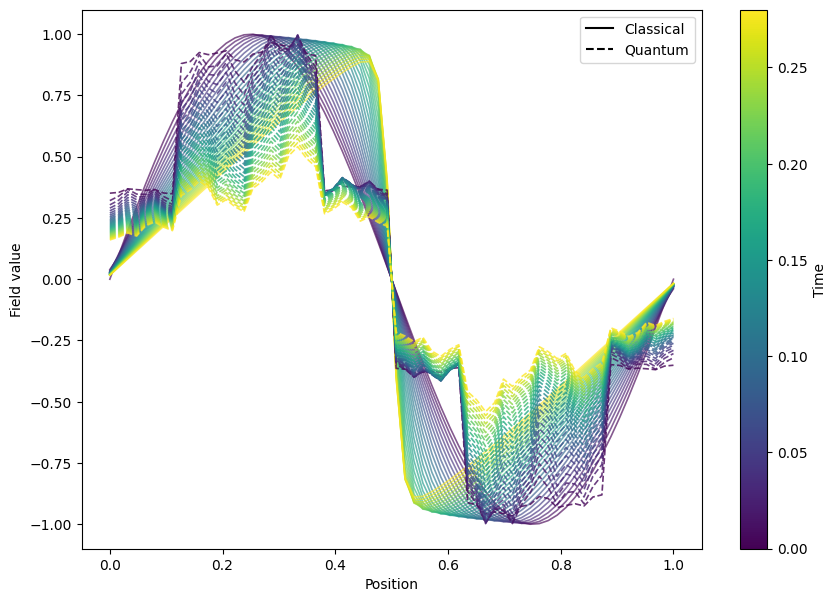

In [20]:
EVOLUTION_FIELDS = "both"       # "classical", "quantum", or "both"
TIMESTEP_STRIDE = 1             # 1 plots every saved timestep

evolution, evolution_ax, evolution_fig = an.plot_run_time_evolution(
    run,
    fields=EVOLUTION_FIELDS,
    timestep_stride=TIMESTEP_STRIDE,
)


In [198]:
evolution_fig.savefig(f"figures/single_runs/single_run_evolution_{DIR_LABEL}_{LABEL}_{EVOLUTION_FIELDS}_{TIMESTEP_STRIDE}.pdf", bbox_inches='tight')

## Evolution-error diagnostics

These plots use the currently selected `run`. The first figure shows the total end-to-end L2 error, the evolution error relative to the encoded-initial classical trajectory, the propagated initial-fit error, derivative and maximum-point errors, and the alignment between the two L2 error vectors. Negative alignment indicates partial error cancellation. The second figure compares the three fields and their signed residuals at `ERROR_TIMESTEP`.


,Timestep,Time,RelativeL2Error,EvolutionRelativeL2Error,PropagatedInitialRelativeL2Error,RelativeDerivativeL2Error,RelativeLinfError,ErrorAlignmentCosine
24,24,0.24,0.000909,0.000912,0.000019,0.001275,0.000883,-0.155129
25,25,0.25,0.000806,0.000809,0.000017,0.001111,0.000737,-0.167310
26,26,0.26,0.000695,0.000697,0.000015,0.000939,0.000601,-0.154289
27,27,0.27,0.000581,0.000583,0.000013,0.000768,0.000490,-0.117520
28,28,0.28,0.000474,0.000475,0.000012,0.000606,0.000392,-0.065556


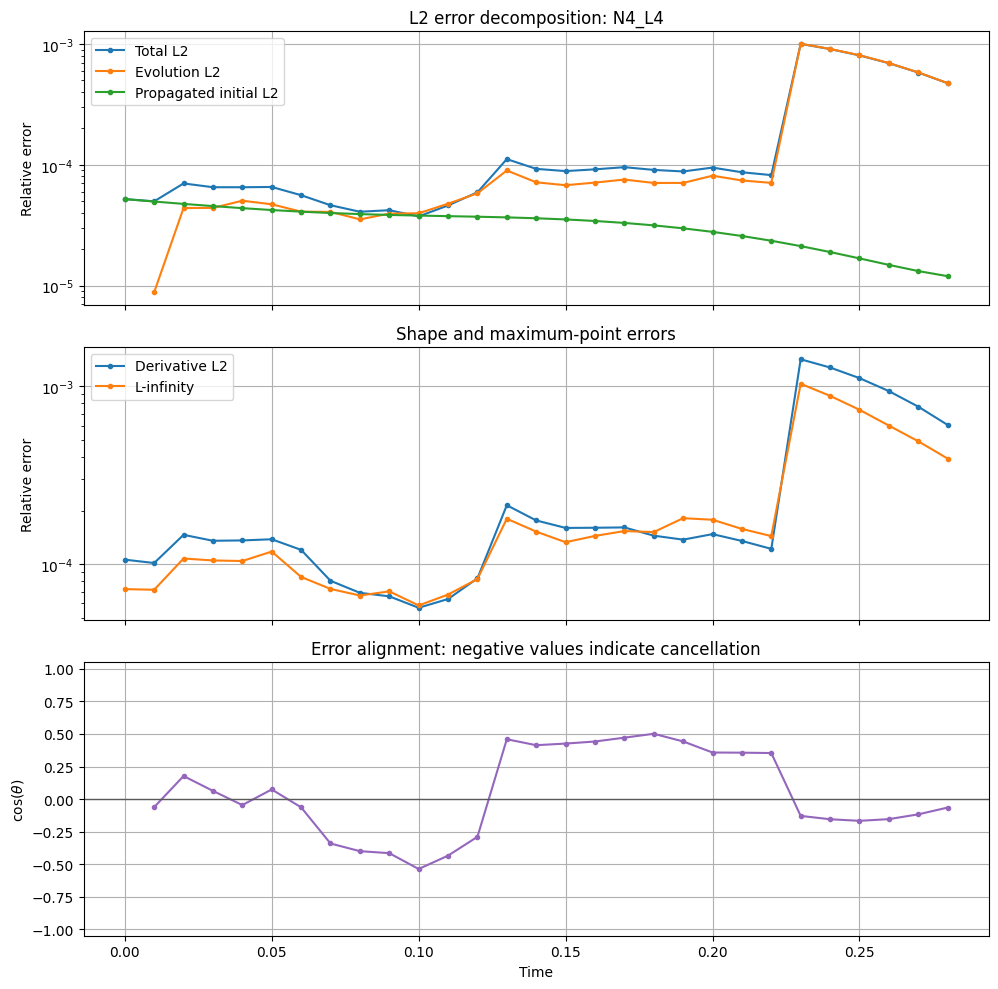

In [43]:
ERROR_LOG_SCALE = True

error_diagnostics, error_axes, error_fig = an.plot_evolution_error_diagnostics(
    run,
    log_error_y=ERROR_LOG_SCALE,
)
error_diagnostics.tail()


timestep                            28.000000
time                                 0.280000
RelativeL2Error                      0.000474
EvolutionRelativeL2Error             0.000475
PropagatedInitialRelativeL2Error     0.000012
RelativeDerivativeL2Error            0.000606
RelativeLinfError                    0.000392
dtype: float64

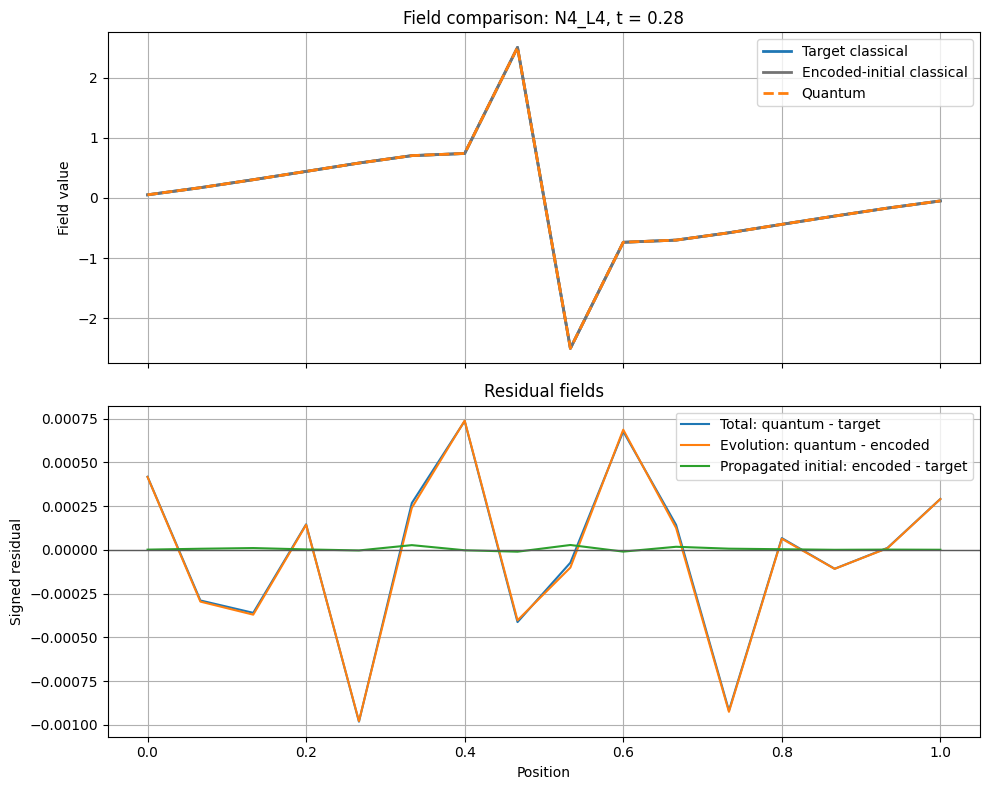

In [29]:
ERROR_TIMESTEP = -1

final_error_comparison, final_error_axes, final_error_fig = an.plot_final_error_diagnostics(
    run,
    timestep=ERROR_TIMESTEP,
)
FINAL_ERROR_METRICS = [
    "timestep", "time", "RelativeL2Error", "EvolutionRelativeL2Error",
    "PropagatedInitialRelativeL2Error", "RelativeDerivativeL2Error",
    "RelativeLinfError",
]
pd.Series({key: final_error_comparison[key] for key in FINAL_ERROR_METRICS})


In [ ]:
# error_fig.savefig(f"figures/single_runs/error_evolution_{DIR_LABEL}_{LABEL}.pdf", bbox_inches="tight")
# final_error_fig.savefig(f"figures/single_runs/error_final_{DIR_LABEL}_{LABEL}.pdf", bbox_inches="tight")


## Expressibility and entangling capability


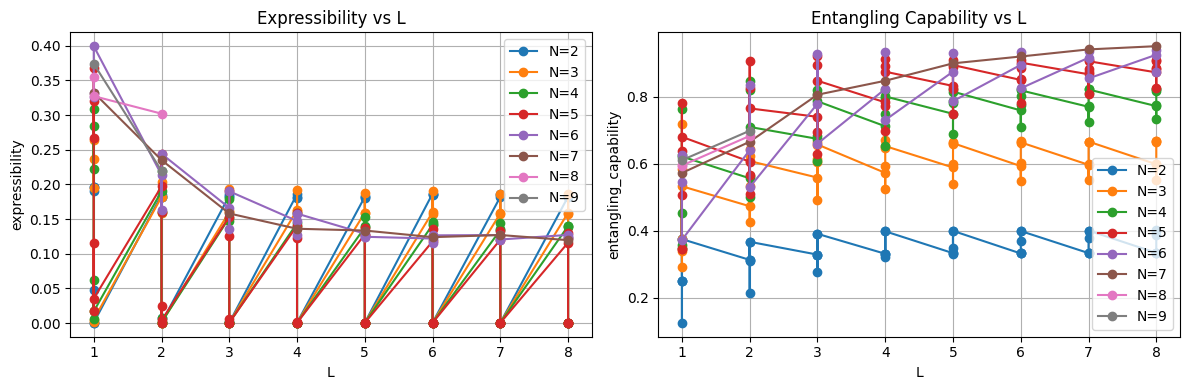

In [9]:
# Add (dir_label, label) pairs here. These select independently saved *_expr results.
# With an empty selection, discover *_expr results and full runs containing either metric.
EXPR_ENTCAP_SELECTION = []

if EXPR_ENTCAP_SELECTION:
    expr_runs = an.load_expr_runs(EXPR_ENTCAP_SELECTION)
else:
    expr_runs = an.discover_expr_runs(include_full_runs=True)

if expr_runs:
    an.plot_expr_entcap_vs_l(expr_runs, n_filter=None)
else:
    print("No selected runs contain expressibility or entangling-capability values.")


## Configurable multi-run comparison table

The table contains N, L, the number of circuit parameters, legacy variance, gradient-run variances, expressibility, entangling capability, circuit, initial state, and final-state comparison metrics. `OverallGradientVariance` is the variance of the reconstructed total cost gradient, including the classical coefficients. `OverlapGradientVariance`, `AdvectionGradientVariance`, and `DiffusionGradientVariance` are calculated from the unscaled quantum combinations $dc_1$, $dc_4-dc_5$, and $dc_2-2dc_1+dc_3$, respectively. `Circuit1GradientVariance` through `Circuit5GradientVariance` are the variances of the five individual circuit derivatives $dc_1$ through $dc_5$. Gradient runs are matched exactly by `(N, L, Circuit, InitialState)`. Independently saved `exp_only` results are matched by `(N, L, Circuit)` and take priority over expressibility or entangling-capability values embedded in full simulation runs.

`InitialRelativeL2Error` measures the initial fit, `PropagatedInitialRelativeL2Error` compares the two classical trajectories initialized from the target and encoded fields, `EvolutionRelativeL2Error` compares the variational field with the classical trajectory initialized from the encoded field, and the existing `RelativeL2Error` is the total end-to-end error. These three final-time errors use the target classical field norm as their common denominator. Field derivatives use the simulation's periodic centered difference and mass uses $M=\Delta x\sum_i u_i$. Relative mass values are `NaN` when their reference mass is effectively zero. Leave `RUN_SELECTION` empty to select every available non-gradient simulation run with saved parameters.

Older manifests do not record a circuit name, so they are shown as `default`. Use `CIRCUIT_OVERRIDES` for older runs whose circuit is known from their label or experiment notes.


In [91]:
RUN_SELECTION = [
    # ("N3", "L2"),
    # ("N4", "L3"),
]

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Optional explicit gradient selection. Leave empty to use all discovered gradient runs.
GRADIENT_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)
gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_SELECTION]
    if GRADIENT_SELECTION
    else an.discover_gradient_runs()
)
expression_runs = an.discover_expr_runs(include_full_runs=False)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
    gradient_runs=gradient_runs,
    expression_runs=expression_runs,
)
run_table


/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:737: RuntimeWarning: overflow encountered in multiply
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:736: RuntimeWarning: invalid value encountered in subtract
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:736: RuntimeWarning: invalid value encountered in add
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:735: RuntimeWarning: invalid value encountered in add
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:737: RuntimeWarning: invalid value encountered in subtract
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:735: RuntimeWarning: invalid value encountered in subtract
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:736: RuntimeWarning: overflow encountered in multiply
  +

,Run,N,L,NumberOfParameters,OptimizationMode,OptimizationTimesteps,TotalOptimizationSteps,MeanOptimizationSteps,MedianOptimizationSteps,MaxOptimizationSteps,...,RelativeL1Error,InitialRelativeL2Error,PropagatedInitialRelativeL2Error,EvolutionRelativeL2Error,RelativeL2Error,RelativeLinfError,RelativeDerivativeL2Error,RelativeDerivativeLinfError,RelativeMassError,NormalizedMassDrift
0,N2_L1,2,1,4,noise_free,28,140,5.000000,5.0,5,...,0.000006,2.461031e-07,1.398127e-07,0.000005,0.000006,0.000006,0.000005,0.000007,NaN,85.453496
1,N2_L1_mixed_sine_modes,2,1,4,noise_free,28,140,5.000000,5.0,5,...,0.000043,9.197203e-09,5.938174e-09,0.000040,0.000040,0.000040,0.000036,0.000040,NaN,10484.173573
2,N2_L1_positive_periodic_wave,2,1,4,noise_free,28,216,7.714286,8.0,8,...,0.000171,6.093190e-08,5.066898e-08,0.000153,0.000153,0.000116,0.000352,0.000306,0.000043,0.000043
3,N2_L1_tapered_gaussian,2,1,4,noise_free,28,144,5.142857,5.0,6,...,0.000719,1.716229e-07,1.445750e-07,0.000643,0.000643,0.000725,0.000632,0.000631,0.000415,0.000415
4,N2_L2,2,2,6,noise_free,28,168,6.000000,6.0,7,...,0.000043,1.052074e-07,8.007352e-08,0.000044,0.000044,0.000059,0.000047,0.000061,NaN,254.837784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,N7_L4,7,4,35,noise_free,28,5962,212.928571,20.0,1379,...,NaN,3.742942e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230.052548
936,N7_L5,7,5,42,noise_free,28,7082,252.928571,41.0,1042,...,NaN,9.253052e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62175.059473
937,N7_L6,7,6,49,noise_free,28,7826,279.500000,27.0,1095,...,NaN,4.162061e-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,759559.009327
938,N7_L7,7,7,56,noise_free,28,6915,246.964286,24.0,1231,...,NaN,9.964430e-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117795.567103


In [76]:
NS = (3, 4, 5, 6)
UNI2_LAYERS = (1, 2, 3)

# N6 UNI2 has not been generated yet.
UNI2_NS = (3, 4, 5)
# UNI2_NS = NS  # Use after generating N6 UNI2 L1–L3.

RUN_SELECTION = [
    # UNI2 reference cases: L1, L2, L3
    *[
        (f"N{n}_uni2", f"L{l}")
        for n in UNI2_NS
        for l in UNI2_LAYERS
    ],

    # Local RY-RZ has the same parameter formula as UNI2
    *[
        (f"N{n}_local_ry_rz", f"L{l}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # GHZ L2, L3, L4 match UNI2 L1, L2, L3
    *[
        (f"N{n}_ghz_orbit", f"L{l + 1}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # Multiscale L3, L5, L7 match UNI2 L1, L2, L3
    *[
        (f"N{n}_multiscale_tree", f"L{2 * l + 1}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # Default L3, L5, L7 match UNI2 L1, L2, L3
    *[
        (f"N{n}", f"L{2 * l + 1}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # Optional brickwork: comment out this whole expansion if unwanted
    # *[
    #     (f"N{n}_brickwork_ring_ry", f"L{2 * l + 1}")
    #     for n in NS
    #     for l in UNI2_LAYERS
    # ],
]

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)
gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_SELECTION]
    if GRADIENT_SELECTION
    else an.discover_gradient_runs()
)
expression_runs = an.discover_expr_runs(include_full_runs=False)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
    gradient_runs=gradient_runs,
    expression_runs=expression_runs,
)

### `run_table` values and available filters

Every column below is available to `plot_run_table` as `X` or `Y`. Any column can also be used in `FILTERS`, and columns can be used for `GROUP_BY` when grouping by that value is meaningful. A filter value can be one allowed value or a list/tuple/set of allowed values; different filters are combined with logical AND. Use an empty dictionary for no filtering.

`X_LABEL` and `Y_LABEL` override the axis labels. `SERIES_LABELS` optionally replaces the complete legend label for every plotted line or scatter series. Its order follows the plotting loops: all groups for the first `Y` column, followed by all groups for the next `Y` column. Leave it as `None` to use automatic labels.

- **Run configuration:** `Run` (saved-run label), `N` (number of qubits), `L` (number of ansatz layers), `NumberOfParameters`, `Circuit`, `InitialState`, and `OptimizationMode`.
- **Optimization effort:** `OptimizationTimesteps` is the number of evolved timesteps with a saved optimizer history. `TotalOptimizationSteps`, `MeanOptimizationSteps`, `MedianOptimizationSteps`, and `MaxOptimizationSteps` summarize the history lengths across those timesteps. For custom Adam modes these are parameter-update iterations (the saved initial cost is excluded); for noise-free Quimb/SciPy and COBYLA runs the old files only preserve loss-function evaluations, not the optimizer's exact internal iteration count. Compare these values only within a common `OptimizationMode`.
- **Variance data:** `Var` (legacy saved cost-gradient variance); `OverallGradientVariance` (reconstructed total cost-gradient variance); `OverlapGradientVariance` ($\operatorname{Var}(dc_1)$); `AdvectionGradientVariance` ($\operatorname{Var}(dc_4-dc_5)$); `DiffusionGradientVariance` ($\operatorname{Var}(dc_2-2dc_1+dc_3)$); and the five individual-circuit values `Circuit1GradientVariance`, `Circuit2GradientVariance`, `Circuit3GradientVariance`, `Circuit4GradientVariance`, and `Circuit5GradientVariance`, corresponding to $\operatorname{Var}(dc_1)$ through $\operatorname{Var}(dc_5)$.
- **Circuit characteristics:** `Expressibility` and `EntanglingCapability`.
- **Final-state comparisons:** `R2`, `Fidelity`, `MSE`, `RelativeL1Error`, `InitialRelativeL2Error`, `PropagatedInitialRelativeL2Error`, `EvolutionRelativeL2Error`, `RelativeL2Error`, `RelativeLinfError`, `RelativeDerivativeL2Error`, `RelativeDerivativeLinfError`, `RelativeMassError`, and `NormalizedMassDrift`.

**Initial states available in the discovered saved simulation runs:** `mixed_sine_modes`, `positive_periodic_wave`, `sine`, and `tapered_gaussian`.

**Circuits available in the discovered saved simulation runs:** `all_to_all_crx`, `block_crx`, `brickwork_ring_ry`, `default`, `ghz_orbit`, `local_ry_rz`, `multiscale_tree`, `ring_ry_rz`, `ring_trainable_crx`, `ring_trainable_crz`, and `uni2`.

The variance columns from gradient runs are `NaN` when no gradient run matches a table row's exact `(N, L, Circuit, InitialState)` configuration. To inspect the choices present after changing `RUN_SELECTION`, use `sorted(run_table["Circuit"].dropna().unique())` and `sorted(run_table["InitialState"].dropna().unique())`.


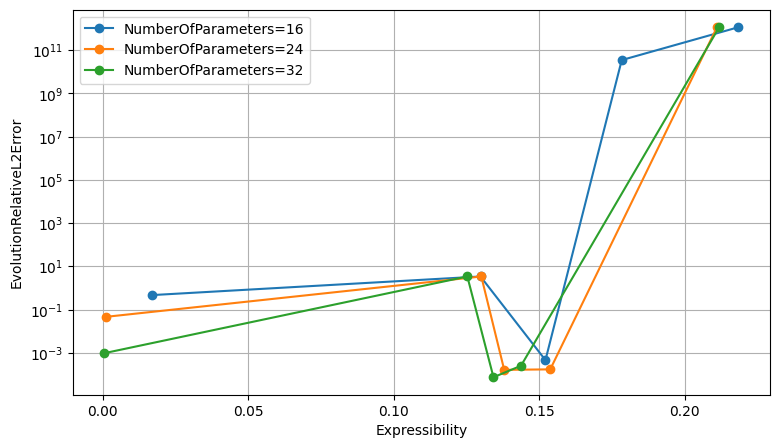

In [90]:
# X accepts one column; Y accepts one column or a list of columns.
# GROUP_BY accepts one column, a list of columns, or None.
X = "Expressibility"
Y = "EvolutionRelativeL2Error"  # e.g. "MeanOptimizationSteps" or a list of columns
GROUP_BY = "NumberOfParameters"
FILTERS = {
    "N": 4,
    "Circuit": ["default","uni2","local_ry_rz","ghz_orbit","multiscale_tree"],
    #"NumberOfParameters": [32],
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = True
X_LABEL = None             # e.g. "Number of parameters"; None uses X
Y_LABEL = None             # e.g. "Expressibility (KL)"; None uses Y
SERIES_LABELS = None       # e.g. ["Default", "GHZ", "Local", "Tree", "UNI2"]
X_LIMITS = None            # e.g. (0, 50); use None for automatic limits
Y_LIMITS = None            # e.g. (0, 0.4); use None for automatic limits

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
)
# filtered_table


In [ ]:
# folder = "exprs"
# name = "expr_default_default_all"
# fig.savefig(f"figures/{folder}/{name}.pdf", bbox_inches='tight')

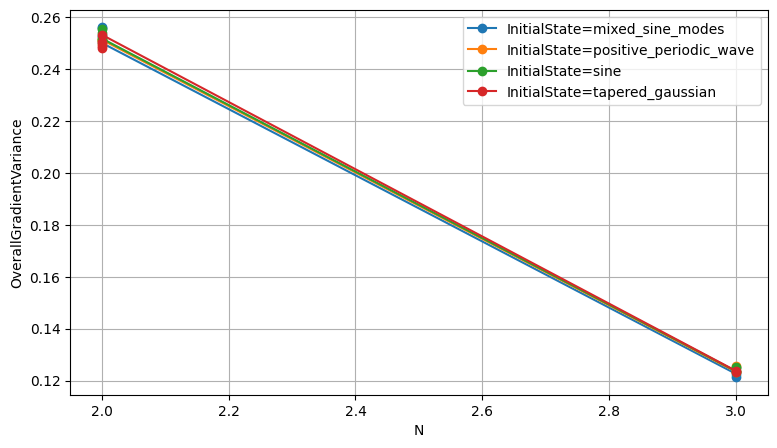

In [64]:
# This second configurable plot uses the same general interface.
X = "N"
Y = "OverallGradientVariance"
GROUP_BY = "InitialState"
FILTERS = {
    "N": [2, 3],
    "Circuit": "default",
    # "L": [1, 2, 3],
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = False
X_LABEL = None             # e.g. "Number of qubits"; None uses X
Y_LABEL = None             # e.g. "Gradient variance"; None uses Y
SERIES_LABELS = None       # e.g. ["Sine", "Gaussian"]
X_LIMITS = None            # e.g. (2, 6); use None for automatic limits
Y_LIMITS = None            # e.g. (1e-8, 1); use None for automatic limits

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
)

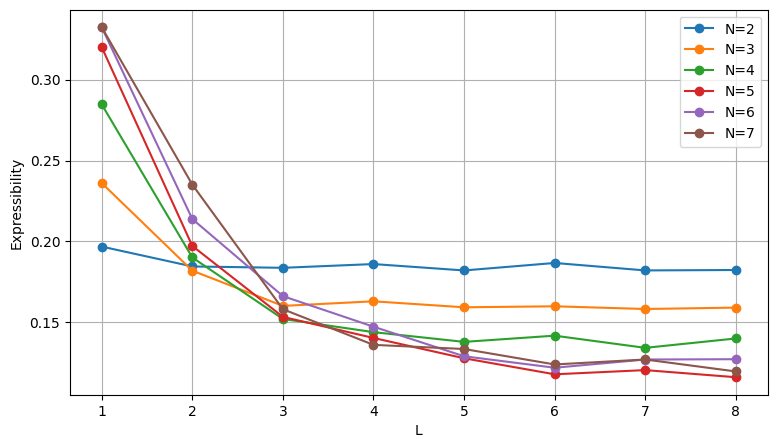

In [93]:
# This second configurable plot uses the same general interface.
X = "L"
Y = "Expressibility"
GROUP_BY = "N"
FILTERS = {
    "N": [2,3,4,5,6,7],
    "Circuit": "default",
    # "L": [1, 2, 3],
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = False
X_LABEL = None             # e.g. "Number of qubits"; None uses X
Y_LABEL = None             # e.g. "Gradient variance"; None uses Y
SERIES_LABELS = None       # e.g. ["Sine", "Gaussian"]
X_LIMITS = None            # e.g. (2, 6); use None for automatic limits
Y_LIMITS = None            # e.g. (1e-8, 1); use None for automatic limits

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
)